# Задачи 4.8, 4.13

- **4.8.** Найти координаты векторов репера Френе $T,N,B$ для заданных пространственных кривых в указанных точках.
- **4.13.** На бинормалях винтовой линии $(a\cos t,a\sin t,bt)$ отложены равные отрезки. Нужно показать, что их концы лежат на другой винтовой линии.

Каркас ниже строит кривую, точку, репер Френе и сдвинутую по бинормали кривую.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, tan, sqrt, pi

try:
    import sympy as sp
except ImportError:
    sp = None

EPS = 1e-9
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

In [2]:
def set_axes_equal_3d(ax):
    """Делает масштабы по осям 3D одинаковыми."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    radius = 0.5 * max([x_range, y_range, z_range])
    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)
    ax.set_xlim3d([x_middle - radius, x_middle + radius])
    ax.set_ylim3d([y_middle - radius, y_middle + radius])
    ax.set_zlim3d([z_middle - radius, z_middle + radius])


def setup_3d(xlim=(-5, 5), ylim=(-5, 5), zlim=(-5, 5), title=None):
    """Создает 3D-систему координат."""
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    if title:
        ax.set_title(title)
    # оси координат
    ax.plot([xlim[0], xlim[1]], [0, 0], [0, 0], linewidth=1)
    ax.plot([0, 0], [ylim[0], ylim[1]], [0, 0], linewidth=1)
    ax.plot([0, 0], [0, 0], [zlim[0], zlim[1]], linewidth=1)
    return fig, ax


def plot_points_3d(ax, points, labels=None):
    labels = labels or [None] * len(points)
    for p, label in zip(points, labels):
        p = np.asarray(p, dtype=float)
        ax.scatter(p[0], p[1], p[2], s=45)
        if label:
            ax.text(p[0], p[1], p[2], '  ' + label)


def plot_parametric_3d(ax, r_func, t_range, n=800, label=None):
    """Рисует пространственную параметрическую кривую t -> (x(t), y(t), z(t))."""
    t = np.linspace(t_range[0], t_range[1], n)
    r = np.asarray(r_func(t), dtype=float)
    ax.plot(r[0], r[1], r[2], label=label)
    if label:
        ax.legend()
    return r


def plot_surface_3d(ax, r_func, u_range, v_range, nu=80, nv=80, alpha=0.45, label=None):
    """Рисует параметрическую поверхность r(u,v). r_func должен возвращать массивы X,Y,Z."""
    u = np.linspace(u_range[0], u_range[1], nu)
    v = np.linspace(v_range[0], v_range[1], nv)
    U, V = np.meshgrid(u, v)
    X, Y, Z = r_func(U, V)
    surf = ax.plot_surface(X, Y, Z, alpha=alpha, linewidth=0, antialiased=True)
    if label:
        surf.set_label(label)
    set_axes_equal_3d(ax)
    return X, Y, Z

In [3]:
def norm(v, axis=0):
    return np.linalg.norm(v, axis=axis)


def normalize(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if n < EPS:
        raise ValueError('Нулевой вектор нельзя нормировать')
    return v / n


def d_curve(r, t, h=1e-5):
    return (np.asarray(r(t + h)) - np.asarray(r(t - h))) / (2 * h)


def dd_curve(r, t, h=1e-4):
    return (np.asarray(r(t + h)) - 2 * np.asarray(r(t)) + np.asarray(r(t - h))) / (h ** 2)


def frenet_frame(r, t, h=1e-5):
    """Численный репер Френе T,N,B для регулярной пространственной кривой."""
    p = np.asarray(r(t), dtype=float)
    r1 = d_curve(r, t, h)
    r2 = dd_curve(r, t, h * 5)
    T = normalize(r1)
    acc_perp = r2 - np.dot(r2, T) * T
    N = normalize(acc_perp)
    B = normalize(np.cross(T, N))
    return p, T, N, B


def draw_frenet_frame(ax, p, T, N, B, scale=1.0):
    """Отрисовывает векторы T,N,B, отложенные от точки p."""
    vectors = [(T, 'T'), (N, 'N'), (B, 'B')]
    for vec, name in vectors:
        ax.quiver(p[0], p[1], p[2], scale*vec[0], scale*vec[1], scale*vec[2], arrow_length_ratio=0.15)
        q = p + scale * vec
        ax.text(q[0], q[1], q[2], name)

## Задача 4.8 — репер Френе

Точка: [1.         0.5        0.33333333]
T = [0.57735027 0.57735027 0.57735027]
N = [-7.07106779e-01 -5.23364161e-09  7.07106784e-01]
B = [ 0.40824829 -0.81649658  0.40824829]
Проверка ортонормированности:
dot(T,N)= -2.2137564043240302e-16 dot(T,B)= 3.671181366790071e-18 dot(N,B)= 8.911751554969002e-18
|T|, |N|, |B| = 1.0 1.0 1.0


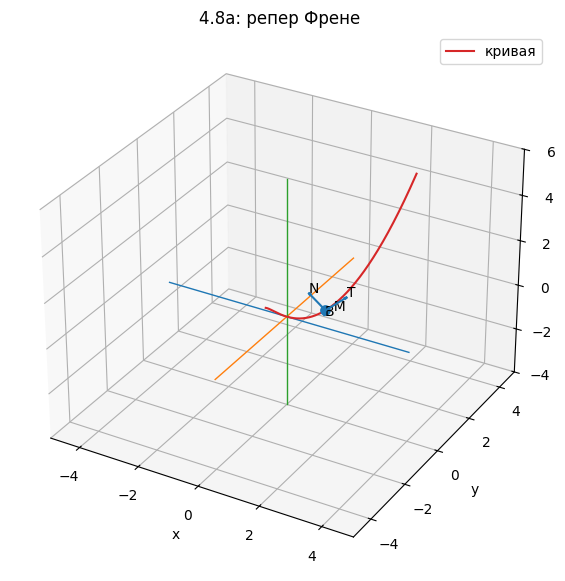

In [10]:
a = 1.5
b = 0.6

curves = {
    '4.8a': {
        'r': lambda t: np.array([t, 0.5*t**2, (1/3)*t**3], dtype=float),
        't0': 1.0,
        't_range': (-1.0, 2.5),
    },
    '4.8b': {
        'r': lambda t: np.array([t*np.sin(t), t*np.cos(t), t*np.exp(t)], dtype=float),
        't0': 0.0,
        't_range': (-1.8, 1.2),
    },
    '4.8c': {
        'r': lambda t: np.array([a*np.cos(t), a*np.sin(t), b*t], dtype=float),
        't0': np.pi/3,
        't_range': (0.0, 4*np.pi),
    },
    '4.8d': {
        'r': lambda t: np.array([a*(t - np.sin(t)), a*(1 - np.cos(t)), 4*a*np.cos(t/2)], dtype=float),
        't0': np.pi/2,
        't_range': (0.0, 4*np.pi),
    },
}

name = '4.8a' 
item = curves[name]
r = item['r']
t0 = item['t0']

p, T, N, B = frenet_frame(r, t0)
print('Точка:', p)
print('T =', T)
print('N =', N)
print('B =', B)
print('Проверка ортонормированности:')
print('dot(T,N)=', np.dot(T, N), 'dot(T,B)=', np.dot(T, B), 'dot(N,B)=', np.dot(N, B))
print('|T|, |N|, |B| =', np.linalg.norm(T), np.linalg.norm(N), np.linalg.norm(B))

fig, ax = setup_3d((-4, 4), (-4, 4), (-4, 6), title=f'{name}: репер Френе')
plot_parametric_3d(ax, r, item['t_range'], n=1000, label='кривая')
plot_points_3d(ax, [p], ['M'])
draw_frenet_frame(ax, p, T, N, B, scale=0.8)
set_axes_equal_3d(ax)
plt.show()

## Задача 4.13 — концы равных отрезков на бинормалях винтовой линии

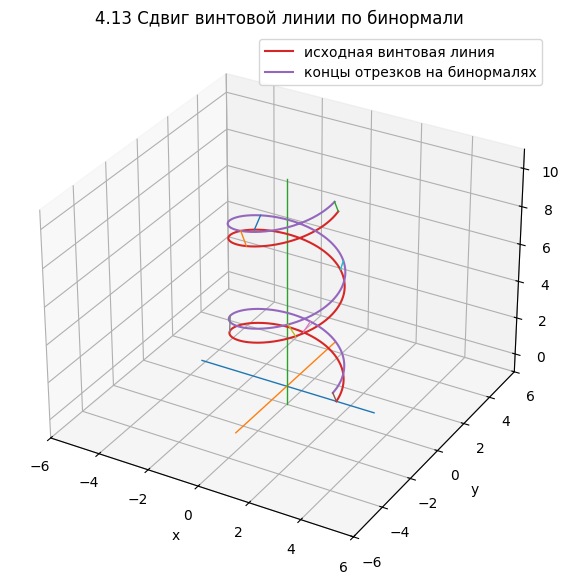

In [11]:
a = 2.0
b = 0.8
segment_length = 0.7

def helix(t, a=a, b=b):
    return np.array([a*np.cos(t), a*np.sin(t), b*t], dtype=float)


def shifted_by_binormal(t, d=segment_length):
    p, T, N, B = frenet_frame(helix, float(t))
    return p + d * B


def shifted_curve(ts):
    pts = np.array([shifted_by_binormal(t) for t in ts])
    return pts.T

fig, ax = setup_3d((-3.5, 3.5), (-3.5, 3.5), (-1, 11), title='4.13 Сдвиг винтовой линии по бинормали')
plot_parametric_3d(ax, helix, (0, 4*np.pi), n=900, label='исходная винтовая линия')
plot_parametric_3d(ax, shifted_curve, (0, 4*np.pi), n=900, label='концы отрезков на бинормалях')

for t0 in np.linspace(0, 4*np.pi, 8):
    p, T, N, B = frenet_frame(helix, t0)
    q = p + segment_length * B
    ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]], linewidth=1)

set_axes_equal_3d(ax)
plt.show()